In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

## Memuat Dataset Training, Validation, dan Testing
---

### Dataset Training (`train`)
Dataset training digunakan untuk melatih model agar dapat mempelajari pola dan hubungan antar fitur. Data diunduh dari Google Drive menggunakan `gdown.download()`, kemudian dibaca ke dalam DataFrame menggunakan `pd.read_csv()`.

In [ ]:
# Menentukan path dataset train
train_file_id = "1D6gWyDVV0NuYWV9JQMRBgIoO6PZPyc3f"
train_output_file = "train.csv"

# Melakukan download dataset train
gdown.download(f"https://drive.google.com/uc?id={train_file_id}", train_output_file)

# Melakukan load dataset train
train = pd.read_csv(train_output_file)

# Menampilkan hasil load dataset train
train.head()

Downloading...
From: https://drive.google.com/uc?id=1D6gWyDVV0NuYWV9JQMRBgIoO6PZPyc3f
To: /content/train.csv
100%|██████████| 13.9M/13.9M [00:00<00:00, 98.3MB/s]


,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,review_volatility,repeat_order_rate,digital_adoption_score,year_revenue,business_tenure_years,class
0,-0.457522,-1.0,1.220992,0.593750,-0.701613,1.381951,1.473251,-0.886364,3
1,0.224523,-1.0,0.471834,0.484375,0.435484,0.153145,0.629630,0.272727,2
2,0.757489,-1.0,1.122773,0.718750,-0.479839,1.170465,1.390947,-0.704545,3
3,-0.637295,-1.0,-0.940299,-0.203125,0.201613,-0.356427,0.234568,0.250000,1
4,0.361590,-1.0,0.644680,0.875000,-0.560484,-0.065634,0.469136,-0.147727,2


### Dataset Validation (`val`)

Dataset validation digunakan untuk mengevaluasi performa model selama proses pengembangan dan membantu dalam pemilihan model maupun tuning hyperparameter. Dataset ini juga diunduh dari Google Drive dan dimuat ke dalam DataFrame.

In [ ]:
# Menentukan path dataset test
val_file_id = "1XX_pnl8ZqdBmFYkGf3BAMYJVGkxKE-78"
val_output_file = "val.csv"

# Melakukan download dataset test
gdown.download(f"https://drive.google.com/uc?id={val_file_id}", val_output_file)

# Melakukan load dataset test
val = pd.read_csv(val_output_file)

# Menampilkan hasil load dataset test
val.head()

Downloading...
From: https://drive.google.com/uc?id=1XX_pnl8ZqdBmFYkGf3BAMYJVGkxKE-78
To: /content/val.csv
100%|██████████| 3.47M/3.47M [00:00<00:00, 106MB/s]


,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,review_volatility,repeat_order_rate,digital_adoption_score,year_revenue,business_tenure_years,class
0,-0.444295,-1.0,-0.026962,0.234375,-0.020161,-1.381039,-1.020576,-0.363636,2
1,-0.467387,-1.0,1.011074,0.687500,-0.451613,1.016408,1.205761,-0.863636,3
2,-0.409693,-1.0,-0.181512,-0.140625,0.092742,-0.290793,0.452675,-0.250000,2
3,-1.665871,-1.0,-0.423207,0.171875,0.286290,0.690975,-0.057613,-0.659091,1
4,-0.708589,-1.0,-0.110255,-0.531250,-0.189516,0.324521,-1.020576,-0.227273,2


### Dataset Testing (`test`)

Dataset testing digunakan sebagai data akhir untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya. Dataset ini digunakan setelah proses pelatihan dan validasi selesai dilakukan.


In [ ]:
# Menentukan path dataset test
test_file_id = "1MJfuYhSNnxVQV1LGYpqHdBytSuC_WKkG"
test_output_file = "test.csv"

# Melakukan download dataset test
gdown.download(f"https://drive.google.com/uc?id={test_file_id}", test_output_file)

# Melakukan load dataset test
test = pd.read_csv(test_output_file)

# Menampilkan hasil load dataset test
test.head()

Downloading...
From: https://drive.google.com/uc?id=1MJfuYhSNnxVQV1LGYpqHdBytSuC_WKkG
To: /content/test.csv
100%|██████████| 4.34M/4.34M [00:00<00:00, 158MB/s]


,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,review_volatility,repeat_order_rate,digital_adoption_score,year_revenue,business_tenure_years,class
0,0.191286,-1.0,0.092922,0.187500,-1.020161,-0.072926,0.283951,-0.068182,2
1,-0.192426,-1.0,0.013962,0.156250,0.084677,-0.904284,0.333333,-0.011364,2
2,-0.189056,-1.0,0.568609,1.375000,-0.979839,0.035552,0.609053,-0.386364,2
3,0.408963,-1.0,-0.268175,-0.140625,-0.040323,0.567001,0.345679,0.261364,2
4,-0.377779,-1.0,0.228214,0.218750,-0.479839,0.340930,0.534979,-0.420455,2


### Tahapan yang Dilakukan
---
1. Menentukan ID file dataset yang tersimpan di Google Drive.
2. Mengunduh dataset menggunakan library `gdown`.
3. Membaca file CSV menggunakan `pandas`.
4. Menyimpan data ke dalam DataFrame (`train`, `val`, dan `test`).
5. Menampilkan lima baris pertama dataset menggunakan fungsi `.head()` untuk memastikan data berhasil dimuat dengan benar.

Dengan pemisahan data menjadi training, validation, dan testing, proses pengembangan model dapat dilakukan secara lebih objektif serta mengurangi risiko overfitting.

# Pemilihan Fitur dan Pemisahan Variabel Target
---

Pada tahap ini dilakukan pemilihan fitur yang akan digunakan sebagai variabel prediktor (input) serta penentuan variabel target yang akan diprediksi oleh model klasifikasi.

In [ ]:
FEATURES = [
    'kepuasan_pelanggan',
    'digital_adoption_score',
    'net_profit_margin',
    'year_revenue',
    'business_tenure_years',
    'peak_hour_latency',
]

TARGET = 'class'

X_train = train[FEATURES]
y_train = train[TARGET]
X_val = val[FEATURES]
y_val = val[TARGET]
X_test = test[FEATURES]

### Fitur yang Digunakan
---
Model menggunakan enam fitur utama, yaitu:
- `kepuasan_pelanggan`
- `digital_adoption_score`
- `net_profit_margin`
- `year_revenue`
- `business_tenure_years`
- `peak_hour_latency`

Fitur-fitur tersebut dipilih karena dianggap memiliki pengaruh terhadap proses klasifikasi yang dilakukan oleh model.

### Variabel Target
---
- `class` digunakan sebagai variabel target yang berisi label kelas yang akan diprediksi oleh model.

### Pembagian Data
---
Data yang telah dimuat sebelumnya kemudian dipisahkan menjadi:
- **X_train** : fitur pada dataset training.
- **y_train** : label target pada dataset training.
- **X_val** : fitur pada dataset validation.
- **y_val** : label target pada dataset validation.
- **X_test** : fitur pada dataset testing.

Pemisahan antara fitur dan target diperlukan agar model dapat mempelajari hubungan antara variabel input dan label yang ingin diprediksi selama proses pelatihan dan evaluasi.

## Feature Engineering dengan Polynomial Features
---

Pada tahap ini dilakukan proses **feature engineering** menggunakan teknik **Polynomial Features** untuk menghasilkan fitur baru dari kombinasi fitur-fitur yang sudah ada.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

### Tujuan
Transformasi polinomial digunakan untuk membantu model menangkap hubungan non-linear antar variabel yang mungkin tidak dapat direpresentasikan dengan baik oleh fitur asli.

### Konfigurasi yang Digunakan
- `degree=2` : menghasilkan fitur hingga pangkat dua serta interaksi antar fitur.
- `include_bias=False` : tidak menambahkan kolom konstanta (bias) karena tidak diperlukan dalam proses pemodelan.

### Proses Transformasi
1. `fit_transform()` diterapkan pada data training untuk mempelajari pola transformasi sekaligus menghasilkan fitur baru.
2. `transform()` diterapkan pada data validation dan testing menggunakan parameter yang telah dipelajari dari data training.
3. Hasil transformasi disimpan dalam:
   - `X_train_poly`
   - `X_val_poly`
   - `X_test_poly`

Dengan penambahan fitur polinomial, model memiliki informasi yang lebih kaya sehingga berpotensi meningkatkan kemampuan prediksi, terutama ketika terdapat hubungan non-linear antar fitur dalam data.

## Pembangunan Model Ensemble Voting Classifier
---
Pada tahap ini dibangun model klasifikasi menggunakan pendekatan **ensemble learning**, yaitu menggabungkan beberapa algoritma machine learning untuk menghasilkan prediksi yang lebih stabil dan akurat dibandingkan menggunakan satu model saja.

In [ ]:
extra_trees = ExtraTreesClassifier(
    n_estimators=500, max_depth=10, min_samples_split=4,
    min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1
)

knn = KNeighborsClassifier(
    n_neighbors=7, weights='distance'
)

hist_gb = HistGradientBoostingClassifier(
    learning_rate=0.03, max_depth=5, max_iter=300,
    min_samples_leaf=8, l2_regularization=1.0, random_state=42
)

ensemble = VotingClassifier(
    estimators=[
        ('et', extra_trees),
        ('knn', knn),
        ('hgb', hist_gb)
    ],
    voting='soft',
    n_jobs=-1
)

### Model yang Digunakan

#### 1. Extra Trees Classifier
`ExtraTreesClassifier` merupakan algoritma berbasis kumpulan decision tree (ensemble tree) yang bekerja dengan tingkat randomisasi yang tinggi. Model ini mampu menangkap pola kompleks pada data serta relatif tahan terhadap overfitting.

Parameter yang digunakan:
- `n_estimators=500` : membangun 500 decision tree.
- `max_depth=10` : membatasi kedalaman pohon.
- `min_samples_split=4` : jumlah minimum sampel untuk melakukan pemisahan node.
- `min_samples_leaf=2` : jumlah minimum sampel pada setiap leaf.
- `class_weight='balanced'` : menangani ketidakseimbangan kelas.
- `random_state=42` : memastikan hasil dapat direproduksi.

#### 2. K-Nearest Neighbors (KNN)
`KNeighborsClassifier` melakukan klasifikasi berdasarkan mayoritas kelas dari tetangga terdekat suatu data.

Parameter yang digunakan:
- `n_neighbors=7` : menggunakan 7 tetangga terdekat.
- `weights='distance'` : tetangga yang lebih dekat memiliki pengaruh lebih besar terhadap prediksi.

#### 3. HistGradientBoosting Classifier
`HistGradientBoostingClassifier` merupakan algoritma boosting yang membangun model secara bertahap dengan memperbaiki kesalahan model sebelumnya. Metode ini efisien dan mampu memberikan performa tinggi pada berbagai kasus klasifikasi.

Parameter yang digunakan:
- `learning_rate=0.03` : mengatur kecepatan pembelajaran model.
- `max_depth=5` : membatasi kompleksitas pohon.
- `max_iter=300` : jumlah iterasi boosting.
- `min_samples_leaf=8` : jumlah minimum sampel pada leaf.
- `l2_regularization=1.0` : regularisasi untuk mengurangi overfitting.

### Ensemble Voting Classifier

Ketiga model tersebut kemudian digabungkan menggunakan `VotingClassifier` dengan metode **soft voting**.

Pada metode soft voting:
1. Setiap model menghasilkan probabilitas prediksi untuk masing-masing kelas.
2. Probabilitas dari seluruh model digabungkan dan dirata-ratakan.
3. Kelas dengan probabilitas tertinggi dipilih sebagai hasil prediksi akhir.

Kombinasi beberapa algoritma yang memiliki karakteristik berbeda diharapkan dapat meningkatkan kemampuan generalisasi model serta menghasilkan performa klasifikasi yang lebih baik dibandingkan model tunggal.

# Evaluasi Model Menggunakan Cross Validation
---
Sebelum model digunakan untuk melakukan prediksi pada data validasi dan testing, dilakukan proses evaluasi menggunakan teknik **Cross Validation** untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    ensemble,
    X_train_poly,
    y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("="*50)
print("CROSS VALIDATION RESULT (ON TRAIN DATA)")
print("="*50)
print(scores)
print(f"Mean F1 Macro : {scores.mean():.4f}\n")

CROSS VALIDATION RESULT (ON TRAIN DATA)
[0.86101571 0.8645426  0.85567267 0.85995048 0.85869188]
Mean F1 Macro : 0.8600



### Stratified K-Fold Cross Validation

Metode yang digunakan adalah **Stratified K-Fold Cross Validation** dengan konfigurasi:
- `n_splits=5` : data training dibagi menjadi 5 subset (fold).
- `shuffle=True` : data diacak sebelum dibagi ke dalam fold.
- `random_state=42` : memastikan hasil pembagian data konsisten pada setiap eksekusi.

Pendekatan stratified digunakan agar proporsi setiap kelas tetap terjaga pada masing-masing fold, sehingga evaluasi menjadi lebih representatif terutama pada dataset yang memiliki distribusi kelas tidak seimbang.

### Proses Evaluasi

Fungsi `cross_val_score()` digunakan untuk:
1. Membagi data training menjadi 5 fold.
2. Melatih model pada 4 fold dan menguji pada 1 fold.
3. Mengulangi proses hingga seluruh fold pernah menjadi data validasi.
4. Menghasilkan skor evaluasi pada setiap iterasi.

### Metrik Evaluasi

Metrik yang digunakan adalah **F1 Macro** (`f1_macro`).

F1 Macro dipilih karena:
- Menggabungkan nilai **Precision** dan **Recall** dalam satu metrik.
- Menghitung skor untuk setiap kelas secara terpisah.
- Memberikan bobot yang sama pada seluruh kelas tanpa memperhatikan jumlah data pada masing-masing kelas.

### Output

Hasil yang ditampilkan meliputi:
- Skor F1 Macro pada setiap fold.
- Nilai rata-rata F1 Macro dari seluruh fold (`Mean F1 Macro`).

Nilai rata-rata F1 Macro digunakan sebagai indikator performa model selama proses pelatihan dan membantu memastikan bahwa model memiliki kemampuan generalisasi yang baik sebelum dilakukan evaluasi lebih lanjut pada data validasi dan testing.

## Evaluasi Model pada Data Validasi
---
Setelah proses cross validation selesai dilakukan, model ensemble kemudian dilatih menggunakan seluruh data training yang telah melalui tahap feature engineering. Selanjutnya, model dievaluasi menggunakan data validasi untuk mengukur kemampuannya dalam melakukan prediksi pada data yang belum pernah digunakan selama proses pelatihan.

In [ ]:
ensemble.fit(X_train_poly, y_train)

y_val_pred = ensemble.predict(X_val_poly)
acc = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred, average='macro')

print("="*50)
print("VALIDATION DATA RESULT")
print("="*50)
print(f"Accuracy : {acc:.4f}")
print(f"F1 Macro : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

VALIDATION DATA RESULT
Accuracy : 0.9102
F1 Macro : 0.8668

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2010
           1       0.91      0.88      0.89      6651
           2       0.94      0.94      0.94     13708
           3       0.74      0.87      0.80      1631

    accuracy                           0.91     24000
   macro avg       0.86      0.88      0.87     24000
weighted avg       0.91      0.91      0.91     24000



### Proses Pelatihan Model

Fungsi `fit()` digunakan untuk melatih model ensemble dengan memanfaatkan data training hasil transformasi polynomial features (`X_train_poly`) beserta label target (`y_train`).

### Prediksi pada Data Validasi

Setelah proses pelatihan selesai, model digunakan untuk menghasilkan prediksi pada data validasi (`X_val_poly`) menggunakan fungsi `predict()`. Hasil prediksi kemudian disimpan pada variabel `y_val_pred`.

### Metrik Evaluasi

Evaluasi performa model dilakukan menggunakan beberapa metrik klasifikasi, yaitu:

#### 1. Accuracy
Accuracy mengukur proporsi prediksi yang benar dibandingkan dengan seluruh jumlah data yang dievaluasi.

Nilai accuracy yang tinggi menunjukkan bahwa model mampu melakukan klasifikasi dengan baik secara keseluruhan.

#### 2. F1 Macro
F1 Macro merupakan rata-rata nilai F1 Score dari setiap kelas tanpa mempertimbangkan jumlah sampel pada masing-masing kelas.

Metrik ini dipilih karena:
- Mempertimbangkan keseimbangan antara Precision dan Recall.
- Cocok digunakan pada permasalahan klasifikasi dengan kemungkinan distribusi kelas yang tidak seimbang.
- Memberikan evaluasi yang lebih adil terhadap seluruh kelas.

#### 3. Classification Report
`classification_report()` digunakan untuk menampilkan ringkasan performa model yang meliputi:
- Precision
- Recall
- F1-Score
- Support (jumlah data pada setiap kelas)

Laporan ini memberikan informasi yang lebih rinci mengenai kemampuan model dalam mengklasifikasikan masing-masing kelas.

### Tujuan Evaluasi

Evaluasi pada data validasi bertujuan untuk memastikan bahwa model tidak hanya memiliki performa yang baik pada data training, tetapi juga mampu melakukan generalisasi dengan baik pada data baru sebelum dilakukan pengujian akhir menggunakan data testing.

## Penyimpanan Model dan Transformer
---
Setelah model selesai dilatih dan dievaluasi, langkah berikutnya adalah menyimpan model serta transformer yang digunakan selama proses preprocessing. Penyimpanan ini memungkinkan model digunakan kembali tanpa perlu melakukan proses pelatihan dari awal.


In [ ]:
print("\n" + "="*50)
print("SAVING MODEL TO JOBLIB")
print("="*50)

# Menyimpan model ensemble dan transformer polynomial secara terpisah
joblib.dump(ensemble, 'ensemble_voting_model.pkl')
joblib.dump(poly, 'polynomial_features.pkl')

print("Model dan Polynomial Transformer berhasil disimpan!")


SAVING MODEL TO JOBLIB
Model dan Polynomial Transformer berhasil disimpan!


### Komponen yang Disimpan

#### 1. Model Ensemble
Model `VotingClassifier` yang telah dilatih disimpan ke dalam file:

- `ensemble_voting_model.pkl`

File ini berisi seluruh parameter dan hasil pembelajaran model sehingga dapat langsung digunakan untuk melakukan prediksi pada data baru.

#### 2. Polynomial Features Transformer
Transformer `PolynomialFeatures` yang digunakan untuk menghasilkan fitur tambahan juga disimpan ke dalam file:

- `polynomial_features.pkl`

Penyimpanan transformer penting dilakukan agar data baru dapat diproses dengan transformasi yang sama seperti data yang digunakan saat pelatihan model.

### Metode Penyimpanan

Library `joblib` digunakan untuk menyimpan objek Python ke dalam file dengan format `.pkl` (Pickle). Metode ini umum digunakan dalam proyek machine learning karena efisien dalam menyimpan model dan objek berukuran besar.

### Tujuan Penyimpanan Model

Dengan menyimpan model dan transformer secara terpisah, proses deployment maupun prediksi pada data baru dapat dilakukan dengan lebih mudah melalui tahapan berikut:

1. Memuat kembali transformer polynomial.
2. Melakukan transformasi pada data baru.
3. Memuat model yang telah dilatih.
4. Menghasilkan prediksi tanpa perlu melakukan training ulang.

Pendekatan ini meningkatkan efisiensi penggunaan model serta mempermudah implementasi pada lingkungan produksi atau aplikasi yang membutuhkan proses inferensi secara berulang.

## Confusion Matrix
---
Untuk memperoleh pemahaman yang lebih mendalam mengenai performa model, dilakukan evaluasi menggunakan **Confusion Matrix**. Metode ini menunjukkan jumlah prediksi yang benar maupun salah untuk setiap kelas sehingga dapat diketahui pola kesalahan yang dilakukan model.

In [ ]:
y_test_pred = ensemble.predict(X_test_poly)

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX TEXT REPR")
print("="*50)
print(cm)


CONFUSION MATRIX TEXT REPR
[[ 1638   328    42     2]
 [  294  5857   500     0]
 [    1   282 12937   488]
 [    0     0   219  1412]]



### Tujuan Penggunaan

Confusion Matrix digunakan untuk:
- Mengidentifikasi jumlah prediksi yang tepat pada setiap kelas.
- Mengetahui kelas yang paling sering mengalami kesalahan klasifikasi.
- Menganalisis performa model secara lebih rinci dibandingkan hanya menggunakan nilai Accuracy atau F1 Score.

### Proses Evaluasi

Fungsi `confusion_matrix()` digunakan untuk membandingkan:
- Label aktual pada data validasi (`y_val`).
- Label hasil prediksi model (`y_val_pred`).

Hasilnya berupa matriks yang menunjukkan distribusi prediksi untuk setiap kombinasi kelas aktual dan kelas prediksi.

### Interpretasi Hasil

Pada Confusion Matrix:
- Nilai pada diagonal utama menunjukkan jumlah prediksi yang benar untuk masing-masing kelas.
- Nilai di luar diagonal menunjukkan jumlah kesalahan klasifikasi.
- Semakin besar nilai pada diagonal utama dan semakin kecil nilai di luar diagonal, maka semakin baik performa model.

### Manfaat Analisis

Analisis Confusion Matrix membantu memahami perilaku model secara lebih detail, terutama dalam mengidentifikasi kelas-kelas yang sulit dibedakan dan menjadi dasar untuk melakukan perbaikan model pada tahap selanjutnya.

## Visualisasi Confusion Matrix
---
Setelah memperoleh nilai Confusion Matrix dalam bentuk matriks numerik, dilakukan visualisasi menggunakan **heatmap** untuk mempermudah interpretasi hasil evaluasi model.

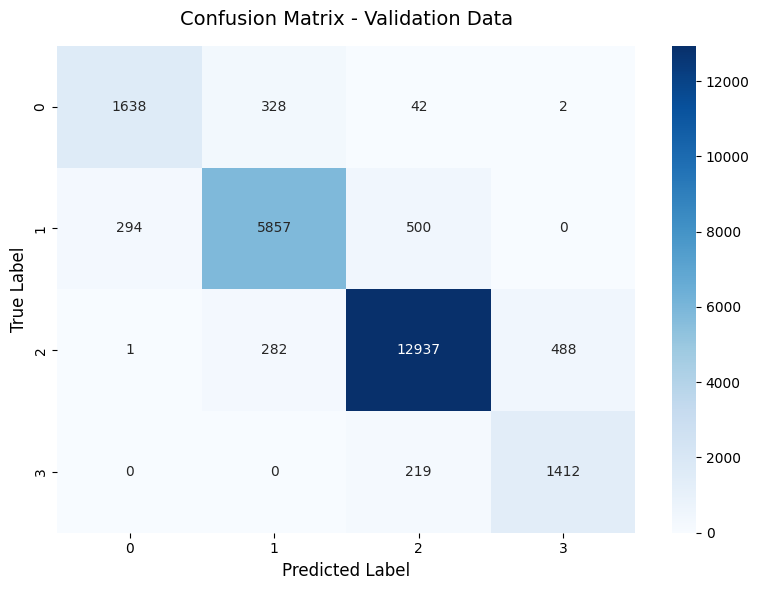

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


labels = sorted(y_val.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix - Validation Data', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


### Tujuan Visualisasi

Visualisasi Confusion Matrix bertujuan untuk:
- Menampilkan distribusi prediksi model secara lebih intuitif.
- Mempermudah identifikasi kelas yang berhasil diprediksi dengan benar.
- Mengetahui pola kesalahan klasifikasi yang dilakukan model.
- Membantu analisis performa model pada setiap kelas.

### Tahapan yang Dilakukan

1. Menentukan label kelas yang terdapat pada data validasi.
2. Membuat heatmap menggunakan library `Seaborn`.
3. Menampilkan nilai pada setiap sel matriks menggunakan parameter `annot=True`.
4. Memberikan label pada sumbu prediksi (*Predicted Label*) dan label aktual (*True Label*).
5. Menambahkan judul grafik untuk memperjelas konteks visualisasi.

### Interpretasi Heatmap

- Sel pada diagonal utama menunjukkan jumlah prediksi yang benar untuk setiap kelas.
- Sel di luar diagonal menunjukkan jumlah kesalahan klasifikasi.
- Semakin gelap warna pada diagonal utama, semakin banyak data yang berhasil diprediksi dengan benar.
- Nilai yang tinggi di luar diagonal mengindikasikan adanya kelas yang sering tertukar oleh model.

### Manfaat Analisis

Visualisasi ini memberikan gambaran yang lebih jelas mengenai kemampuan model dalam membedakan setiap kelas serta membantu mengidentifikasi area yang masih memerlukan perbaikan untuk meningkatkan performa klasifikasi.

## Pembuatan Pipeline Model
---
Pada tahap ini dibuat sebuah **Pipeline** yang menggabungkan proses feature engineering dan model klasifikasi ke dalam satu alur kerja yang terintegrasi.

In [ ]:
full_model_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('ensemble_model', ensemble)
])



### Tujuan Penggunaan Pipeline

Pipeline digunakan untuk:
- Mengotomatisasi proses preprocessing dan prediksi dalam satu objek.
- Memastikan data baru diproses dengan langkah yang sama seperti data saat pelatihan.
- Mengurangi risiko kesalahan saat proses deployment atau inferensi.
- Membuat kode lebih ringkas, terstruktur, dan mudah dipelihara.

### Tahapan dalam Pipeline

Pipeline yang dibangun terdiri dari dua tahap utama:

#### 1. Polynomial Features
Tahap pertama menggunakan `PolynomialFeatures` dengan:
- `degree=2`
- `include_bias=False`

Transformasi ini bertujuan menghasilkan fitur-fitur baru berupa interaksi dan kombinasi antar fitur sehingga model dapat menangkap hubungan non-linear yang mungkin terdapat dalam data.

#### 2. Ensemble Model
Tahap kedua menggunakan model ensemble `VotingClassifier` yang sebelumnya telah dibangun dari kombinasi:
- Extra Trees Classifier
- K-Nearest Neighbors (KNN)
- HistGradientBoosting Classifier

Model ini bertugas melakukan proses klasifikasi berdasarkan fitur hasil transformasi polynomial.

### Keuntungan Pipeline

Dengan adanya pipeline, proses prediksi pada data baru dapat dilakukan secara langsung tanpa perlu menjalankan tahap preprocessing secara manual. Ketika data dimasukkan ke dalam pipeline, transformasi polynomial akan dilakukan terlebih dahulu, kemudian hasilnya akan diteruskan ke model ensemble untuk menghasilkan prediksi.

Pendekatan ini sangat bermanfaat pada tahap deployment karena memastikan konsistensi antara proses pelatihan dan proses penggunaan model di lingkungan produksi.

## Evaluasi Pipeline Menggunakan Cross Validation
---
Setelah seluruh tahapan preprocessing dan model digabungkan ke dalam pipeline, dilakukan evaluasi kembali menggunakan **Stratified K-Fold Cross Validation**. Tujuannya adalah untuk mengukur performa pipeline secara menyeluruh dengan alur kerja yang sama seperti saat digunakan pada data baru.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    full_model_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(f"Mean F1 Macro CV: {scores.mean():.4f}\n")

Mean F1 Macro CV: 0.8600




### Mengapa Evaluasi Pipeline?

Pada tahap sebelumnya, transformasi polynomial dilakukan secara terpisah sebelum model dilatih. Namun, dalam implementasi nyata, preprocessing dan model akan berjalan secara bersamaan melalui pipeline. Oleh karena itu, evaluasi terhadap pipeline perlu dilakukan untuk memastikan seluruh proses bekerja dengan baik sebagai satu kesatuan.

### Metode yang Digunakan

Evaluasi dilakukan menggunakan **Stratified K-Fold Cross Validation** dengan konfigurasi:

- `n_splits=5` : data dibagi menjadi 5 fold.
- `shuffle=True` : data diacak sebelum pembagian fold.
- `random_state=42` : memastikan hasil evaluasi dapat direproduksi.

Pendekatan stratified digunakan untuk menjaga proporsi kelas pada setiap fold sehingga hasil evaluasi lebih representatif.

### Proses Evaluasi

Pada setiap iterasi cross validation:

1. Data training dibagi menjadi data latih dan data validasi sementara.
2. Pipeline melakukan transformasi polynomial secara otomatis pada data latih.
3. Model ensemble dilatih menggunakan hasil transformasi tersebut.
4. Pipeline menghasilkan prediksi pada fold validasi.
5. Nilai F1 Macro dihitung untuk setiap fold.

### Metrik Evaluasi

Metrik yang digunakan adalah **F1 Macro**, karena:
- Mempertimbangkan keseimbangan antara Precision dan Recall.
- Memberikan bobot yang sama untuk setiap kelas.
- Cocok digunakan untuk mengevaluasi performa klasifikasi secara menyeluruh.

### Output

Hasil yang ditampilkan berupa **rata-rata F1 Macro dari seluruh fold** (`Mean F1 Macro CV`), yang digunakan sebagai indikator kemampuan generalisasi pipeline terhadap data yang belum pernah dilihat sebelumnya.

Nilai ini menjadi acuan penting untuk menilai apakah kombinasi preprocessing dan model yang dibangun sudah cukup stabil dan siap digunakan pada tahap deployment maupun pengujian akhir.

## Pelatihan dan Evaluasi Pipeline pada Data Validasi
---
Setelah pipeline selesai dibangun, langkah berikutnya adalah melatih pipeline menggunakan seluruh data training dan mengevaluasi performanya pada data validasi.

In [ ]:
full_model_pipeline.fit(X_train, y_train)


y_val_pred = full_model_pipeline.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2010
           1       0.91      0.88      0.89      6651
           2       0.94      0.94      0.94     13708
           3       0.74      0.87      0.80      1631

    accuracy                           0.91     24000
   macro avg       0.86      0.88      0.87     24000
weighted avg       0.91      0.91      0.91     24000





### Proses Pelatihan Pipeline

Fungsi `fit()` digunakan untuk melatih pipeline menggunakan:

- `X_train` sebagai data fitur.
- `y_train` sebagai label target.

Karena menggunakan `Pipeline`, proses transformasi fitur dan pelatihan model dilakukan secara otomatis dalam satu alur kerja. Data terlebih dahulu ditransformasikan menggunakan **Polynomial Features**, kemudian hasilnya digunakan untuk melatih model ensemble.

### Prediksi pada Data Validasi

Setelah proses pelatihan selesai, pipeline digunakan untuk menghasilkan prediksi pada data validasi (`X_val`) melalui fungsi `predict()`.

Pada tahap ini:
1. Data validasi secara otomatis ditransformasikan menggunakan Polynomial Features.
2. Hasil transformasi diteruskan ke model ensemble.
3. Model menghasilkan prediksi kelas untuk setiap observasi pada data validasi.

### Evaluasi Menggunakan Classification Report

Performa model dievaluasi menggunakan `classification_report()`, yang menyajikan beberapa metrik penting untuk setiap kelas, yaitu:

- **Precision** : kemampuan model dalam menghasilkan prediksi positif yang benar.
- **Recall** : kemampuan model dalam menemukan seluruh data yang benar-benar termasuk dalam suatu kelas.
- **F1-Score** : rata-rata harmonik antara Precision dan Recall.
- **Support** : jumlah data aktual pada masing-masing kelas.

Selain metrik per kelas, laporan ini juga menampilkan:
- **Accuracy** keseluruhan model.
- **Macro Average** sebagai rata-rata sederhana seluruh kelas.
- **Weighted Average** sebagai rata-rata yang mempertimbangkan jumlah data pada setiap kelas.

### Tujuan Evaluasi

Evaluasi pada data validasi dilakukan untuk mengukur kemampuan pipeline dalam melakukan generalisasi terhadap data yang belum pernah digunakan selama proses pelatihan. Hasil dari classification report memberikan gambaran yang lebih detail mengenai performa model pada masing-masing kelas dibandingkan hanya melihat nilai accuracy secara keseluruhan.

## Menyimpan dan Memuat Pipeline Model
---
Setelah pipeline selesai dilatih dan dievaluasi, langkah selanjutnya adalah menyimpan model agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang. Selain itu, pipeline yang telah disimpan juga dapat dimuat kembali untuk keperluan prediksi maupun deployment.

In [ ]:
joblib.dump(full_model_pipeline, 'PolyEns.pkl')
print("done")

done


In [ ]:
joblib.dump(full_model_pipeline, 'PolyEns.joblib')
print("done")

done


In [ ]:
preprocessor = joblib.load("pipeline_investor.joblib")



### Penyimpanan Pipeline

Pipeline disimpan menggunakan library `joblib` ke dalam dua format file:

- `PolyEns.pkl`
- `PolyEns.joblib`

Kedua file tersebut berisi objek pipeline lengkap yang mencakup:
- Transformasi Polynomial Features.
- Model Ensemble Voting Classifier.
- Parameter dan hasil pembelajaran yang telah diperoleh selama proses training.

Penyimpanan model memungkinkan proses inferensi dilakukan secara lebih efisien karena model tidak perlu dilatih ulang setiap kali digunakan.

### Memuat Pipeline yang Telah Disimpan

Fungsi `joblib.load()` digunakan untuk memuat kembali pipeline yang telah disimpan sebelumnya, dalam hal ini file:

- `pipeline_investor.joblib`

Objek yang berhasil dimuat disimpan ke dalam variabel `preprocessor` sehingga dapat digunakan kembali untuk melakukan preprocessing maupun prediksi pada data baru.

### Manfaat Penyimpanan Model

Dengan menyimpan pipeline ke dalam file, model dapat:
- Digunakan kembali tanpa proses training ulang.
- Diintegrasikan ke dalam aplikasi atau sistem deployment.
- Dibagikan kepada pengguna lain dengan konfigurasi yang sama.
- Menjamin konsistensi proses preprocessing dan prediksi pada data baru.

Tahapan ini merupakan bagian penting dalam siklus machine learning karena menjembatani proses pengembangan model dengan implementasi pada lingkungan produksi.

## Implementasi Inferensi pada Data Baru
---
Pada tahap ini dilakukan proses **inferensi**, yaitu penggunaan model yang telah dilatih untuk memprediksi kelas pada data baru yang belum pernah digunakan selama proses training maupun evaluasi.

In [ ]:
import pandas as pd
import joblib
import numpy as np

# 1. Load bundle preprocessor dan model
bundle = joblib.load('pipeline_investor.joblib')
model = joblib.load('PolyEns.joblib')

# Ekstrak komponen dari bundle
preprocessor = bundle['preprocessor']
inverse_mapping = bundle['inverse_mapping']

# 2. Menyiapkan data asli untuk inferensi
FEATURES_ORDER = [
    'kepuasan_pelanggan',
    'digital_adoption_score',
    'net_profit_margin',
    'year_revenue',
    'business_tenure_years',
    'peak_hour_latency'
]

data_samples = [
    # Elite
    {'kepuasan_pelanggan': 5, 'digital_adoption_score': 6, 'net_profit_margin': 30, 'year_revenue': 80197692, 'business_tenure_years': 2, 'peak_hour_latency': 'low'},
    {'kepuasan_pelanggan': 5, 'digital_adoption_score': 7, 'net_profit_margin': 34, 'year_revenue': 128570904, 'business_tenure_years': 5, 'peak_hour_latency': 'low'},
    # Growth
    {'kepuasan_pelanggan': 5, 'digital_adoption_score': 4, 'net_profit_margin': 23, 'year_revenue': 80168592, 'business_tenure_years': 9, 'peak_hour_latency': 'low'},
    {'kepuasan_pelanggan': 4, 'digital_adoption_score': 1, 'net_profit_margin': 4, 'year_revenue': 69829212, 'business_tenure_years': 8, 'peak_hour_latency': 'medium'},
    # Struggling
    {'kepuasan_pelanggan': 4, 'digital_adoption_score': 3, 'net_profit_margin': -10, 'year_revenue': 62836848, 'business_tenure_years': 1, 'peak_hour_latency': 'medium'},
    # Critical
    {'kepuasan_pelanggan': 3, 'digital_adoption_score': 1, 'net_profit_margin': -18, 'year_revenue': 61616384, 'business_tenure_years': 11, 'peak_hour_latency': 'medium'}
]

new_data = pd.DataFrame(data_samples)[FEATURES_ORDER]

print("Data mentah (Raw Data):")
display(new_data)

# 3. Jalankan pipeline inferensi agar SINKRON
# Langkah A: Transformasi data mentah menggunakan preprocessor dari pipeline_investor.joblib
X_processed = preprocessor.transform(new_data)

# Langkah B: Prediksi menggunakan model PolyEns.joblib
# Kita masukkan X_processed (hasil transform), BUKAN new_data (mentah)
predictions_encoded = model.predict(X_processed)

# 4. Balikkan ke label asli
final_labels = [inverse_mapping[p] for p in predictions_encoded]

# 5. Hasil Akhir
results = new_data.copy()
results['predicted_class'] = final_labels

print("\nHasil Inferensi (Sudah Sinkron dengan Preprocessor):")
display(results)

Data asli untuk inferensi:


,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,digital_adoption_score,year_revenue,business_tenure_years
0,30,5,low,6,80197692,2
1,34,5,low,7,128570904,5
2,23,5,low,4,80168592,9
3,4,4,medium,1,69829212,8
4,-10,4,medium,3,62836848,1
5,-18,3,medium,1,61616384,11



Hasil Inferensi:


,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,digital_adoption_score,year_revenue,business_tenure_years,predicted_class_id,predicted_label
0,30,5,low,6,80197692,2,1,Struggling
1,34,5,low,7,128570904,5,1,Struggling
2,23,5,low,4,80168592,9,2,Growth
3,4,4,medium,1,69829212,8,2,Growth
4,-10,4,medium,3,62836848,1,1,Struggling
5,-18,3,medium,1,61616384,11,2,Growth




### Tujuan

Tahap inferensi bertujuan untuk menguji bagaimana model bekerja dalam kondisi nyata dengan menerima data mentah (*raw data*), melakukan preprocessing yang sama seperti saat pelatihan, dan menghasilkan prediksi kelas secara otomatis.

### Memuat Model dan Preprocessor

Dua file yang telah disimpan sebelumnya dimuat kembali menggunakan `joblib`, yaitu:

- `pipeline_investor.joblib`
  - Berisi komponen preprocessing yang digunakan selama pelatihan.
  - Termasuk informasi pemetaan label (*inverse mapping*).

- `PolyEns.joblib`
  - Berisi model klasifikasi yang telah dilatih.

Dengan memuat kedua komponen tersebut, proses inferensi dapat dilakukan secara konsisten dengan alur yang digunakan saat training.

### Menyiapkan Data Baru

Data inferensi dibuat dalam bentuk beberapa contoh UMKM dengan fitur:

- `kepuasan_pelanggan`
- `digital_adoption_score`
- `net_profit_margin`
- `year_revenue`
- `business_tenure_years`
- `peak_hour_latency`

Data kemudian dikonversi menjadi DataFrame dengan urutan fitur yang sama seperti saat model dilatih untuk memastikan kompatibilitas dengan pipeline.

### Proses Inferensi

Tahapan inferensi dilakukan sebagai berikut:

#### 1. Transformasi Data

Data mentah diproses menggunakan preprocessor yang telah disimpan sebelumnya:

```python
X_processed = preprocessor.transform(new_data)
```

Tahap ini memastikan bahwa seluruh transformasi yang digunakan saat pelatihan diterapkan kembali secara identik pada data baru.

#### 2. Prediksi Model

Data yang telah diproses kemudian diberikan ke model untuk menghasilkan prediksi:

```python
predictions_encoded = model.predict(X_processed)
```

Output yang dihasilkan masih berupa label numerik (encoded label).

#### 3. Konversi ke Label Asli

Hasil prediksi numerik dikonversi kembali ke nama kelas asli menggunakan `inverse_mapping`:

```python
final_labels = [inverse_mapping[p] for p in predictions_encoded]
```

Langkah ini membuat hasil prediksi lebih mudah dipahami oleh pengguna.

### Hasil Inferensi

Hasil akhir disajikan dalam bentuk tabel yang berisi:

- Data fitur asli.
- Kelas hasil prediksi (`predicted_class`).

Dengan pendekatan ini, proses inferensi berjalan secara sinkron dengan proses pelatihan sehingga risiko perbedaan preprocessing (*training-serving skew*) dapat diminimalkan. Hal ini penting untuk memastikan bahwa model memberikan prediksi yang konsisten ketika diimplementasikan pada lingkungan produksi.